# Simulate White Dwarf Binary Light Curves with `lcurve-rs`

This notebook samples detached white dwarf binary parameters, evaluates `lcurve-rs`, and injects the synthetic signal onto real SCoPe/ZTF observing cadences. The intended workflow is:

1. Load random non-variable Gaia WD/SCoPe matches from `scope_gaia_crossmatch.ipynb`.
2. Fetch or load each matched object's real SCoPe light curve.
3. Use the real observation times and magnitude uncertainties as the sampling/noise model.
4. Generate synthetic WDB magnitudes suitable for feature generation or ML experiments.


In [46]:
from pathlib import Path
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_SRC = Path.cwd() / "src"
if PROJECT_SRC.exists() and str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from wdb_ml.bootstrap import bootstrap_paths

paths = bootstrap_paths()
SCOPE_ML_ROOT = paths["scope_ml"]
LCURVE_ROOT = paths["lcurve"]
LCURVE_PYTHON = paths["lcurve_python"]
MODEL_TEMPLATE = LCURVE_ROOT / "test_data" / "test_model.dat"

import lcurve_rs
from penquins import Kowalski

rng = np.random.default_rng(42)


## SCoPe/Kowalski Setup

This uses `config.yaml` in the current `wdb-ml` directory, matching `scope_gaia_crossmatch.ipynb`. Environment variables are not required if your config already has tokens.


In [47]:
def load_config(config_path="config.yaml"):
    with open(config_path, "r") as f:
        return yaml.load(f, Loader=yaml.FullLoader)


config = load_config()

timeout = config["kowalski"]["timeout"]
hosts = [
    host
    for host, host_config in config["kowalski"]["hosts"].items()
    if host_config.get("token") is not None
]
instances = {
    host: {
        "protocol": config["kowalski"]["protocol"],
        "port": config["kowalski"]["port"],
        "host": f"{host}.caltech.edu",
        "token": config["kowalski"]["hosts"][host]["token"],
    }
    for host in hosts
}

kowalski_instances = Kowalski(timeout=timeout, instances=instances)
SOURCES_CATALOG = config["kowalski"]["collections"]["sources"]
MAX_TIMESTAMP_HJD = config["kowalski"].get("max_timestamp_hjd")

SOURCES_CATALOG, hosts


('ZTF_sources_20240515', ['kowalski', 'gloria', 'melman'])

## Parameter Priors

Use `prior_mode = "informed"` for training-set injections that should resemble compact detached WD binaries. Use `prior_mode = "uninformed"` to explore a broader parameter space and discover failure modes.

The parameters varied here are deliberately limited to the stable detached-binary subset of `lcurve`: mass ratio `q`, inclination `iangle`, scaled radii `r1/r2`, temperatures `t1/t2`, orbital period, phase offset, limb darkening, gravity darkening, and beaming. Disc and bright-spot parameters stay disabled in the template model.

In [48]:
prior_mode = "informed"  # "informed" or "uninformed"
min_clean_amp_mag = 0.05  # 5th-to-95th percentile amplitude required before adding noise
max_acceptance_attempts = 100

PRIOR_NOTES = pd.DataFrame([
    {"parameter": "period_days", "informed": "log-uniform 0.003-0.5 d", "uninformed": "log-uniform 0.002-2 d", "reason": "Detached compact WDBs are commonly minutes-to-hours; broad mode includes longer binaries."},
    {"parameter": "q", "informed": "uniform 0.2-1.5", "uninformed": "uniform 0.05-3", "reason": "Covers comparable-mass DWDs while allowing asymmetric systems."},
    {"parameter": "iangle", "informed": "isotropic, restricted 75-90 deg", "uninformed": "isotropic 50-90 deg", "reason": "High inclination is needed for eclipses; lower inclinations stress non-eclipsing morphology."},
    {"parameter": "r1, r2", "informed": "log-uniform 0.008-0.04", "uninformed": "log-uniform 0.005-0.08", "reason": "Scaled WD radii; kept below Roche-like extremes for stable detached shapes."},
    {"parameter": "t1, t2", "informed": "log-uniform 6k-50k K", "uninformed": "log-uniform 4k-80k K", "reason": "WD effective-temperature range; broad mode includes very cool/hot tails."},
    {"parameter": "phase0", "informed": "uniform 0-1", "uninformed": "uniform 0-1", "reason": "Random ephemeris relative to ZTF observations."},
    {"parameter": "amplitude_scale", "informed": "log-uniform 0.5-8", "uninformed": "log-uniform 0.1-15", "reason": "Rescales raw lcurve contrast after anchoring to real ZTF magnitudes; larger values are often needed because raw detached-WD flux contrast can be below ZTF noise."},
    {"parameter": "blend_fraction", "informed": "uniform 0-0.5", "uninformed": "uniform 0-0.9", "reason": "Extra constant light from blending/background reduces apparent variability."},
])

PRIOR_NOTES


,parameter,informed,uninformed,reason
0,period_days,log-uniform 0.003-0.5 d,log-uniform 0.002-2 d,Detached compact WDBs are commonly minutes-to-...
1,q,uniform 0.2-1.5,uniform 0.05-3,Covers comparable-mass DWDs while allowing asy...
2,iangle,"isotropic, restricted 75-90 deg",isotropic 50-90 deg,High inclination is needed for eclipses; lower...
3,"r1, r2",log-uniform 0.008-0.04,log-uniform 0.005-0.08,Scaled WD radii; kept below Roche-like extreme...
4,"t1, t2",log-uniform 6k-50k K,log-uniform 4k-80k K,WD effective-temperature range; broad mode inc...
5,phase0,uniform 0-1,uniform 0-1,Random ephemeris relative to ZTF observations.
6,amplitude_scale,log-uniform 0.5-8,log-uniform 0.1-15,Rescales raw lcurve contrast after anchoring t...
7,blend_fraction,uniform 0-0.5,uniform 0-0.9,Extra constant light from blending/background ...


In [49]:
def log_uniform(rng, low, high):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))


def isotropic_inclination(rng, low_deg, high_deg):
    """Sample inclinations uniformly in cos(i), restricted to [low, high]."""
    cos_low = np.cos(np.deg2rad(high_deg))
    cos_high = np.cos(np.deg2rad(low_deg))
    return float(np.rad2deg(np.arccos(rng.uniform(cos_low, cos_high))))


def sample_wdb_params(rng, mode="informed"):
    if mode == "informed":
        params = {
            "period_days": log_uniform(rng, 0.003, 0.5),
            "q": rng.uniform(0.2, 1.5),
            "iangle": isotropic_inclination(rng, 75.0, 89.8),
            "r1": log_uniform(rng, 0.008, 0.04),
            "r2": log_uniform(rng, 0.008, 0.04),
            "t1": log_uniform(rng, 6_000, 50_000),
            "t2": log_uniform(rng, 5_000, 40_000),
            "phase0": rng.uniform(0.0, 1.0),
            "amplitude_scale": log_uniform(rng, 0.5, 8.0),
            "blend_fraction": rng.uniform(0.0, 0.5),
        }
    elif mode == "uninformed":
        params = {
            "period_days": log_uniform(rng, 0.002, 2.0),
            "q": rng.uniform(0.05, 3.0),
            "iangle": isotropic_inclination(rng, 50.0, 89.8),
            "r1": log_uniform(rng, 0.005, 0.08),
            "r2": log_uniform(rng, 0.005, 0.08),
            "t1": log_uniform(rng, 4_000, 80_000),
            "t2": log_uniform(rng, 4_000, 80_000),
            "phase0": rng.uniform(0.0, 1.0),
            "amplitude_scale": log_uniform(rng, 0.1, 15.0),
            "blend_fraction": rng.uniform(0.0, 0.9),
        }
    else:
        raise ValueError("mode must be 'informed' or 'uninformed'")

    params.update({
        "spin1": 1.0,
        "spin2": 1.0,
        "ldc1_1": rng.uniform(0.2, 0.7),
        "ldc2_1": rng.uniform(0.2, 0.7),
        "ldc1_2": 0.0,
        "ldc1_3": 0.0,
        "ldc1_4": 0.0,
        "ldc2_2": 0.0,
        "ldc2_3": 0.0,
        "ldc2_4": 0.0,
        "gravity_dark1": 0.25,
        "gravity_dark2": 0.25,
        "beam_factor1": rng.uniform(0.0, 2.0),
        "beam_factor2": rng.uniform(0.0, 2.0),
    })
    return params


## Build and Evaluate an `lcurve` Model

`lcurve-rs` can accept explicit time arrays. Here we convert real HJD timestamps into orbital phase and evaluate the model in phase units. This avoids ambiguity about absolute ephemeris units and makes the simulation easy to inject onto any real SCoPe cadence.

In [50]:
LCURVE_PARAMS = [
    "q", "iangle", "r1", "r2", "t1", "t2", "spin1", "spin2",
    "ldc1_1", "ldc1_2", "ldc1_3", "ldc1_4",
    "ldc2_1", "ldc2_2", "ldc2_3", "ldc2_4",
    "gravity_dark1", "gravity_dark2", "beam_factor1", "beam_factor2",
]


def build_lcurve_model(params, template_path=MODEL_TEMPLATE):
    model = lcurve_rs.Model(str(template_path))
    for name in LCURVE_PARAMS:
        if name in params:
            model.set_param(name, float(params[name]))

    # We feed orbital phase directly, so keep model period/t0 in phase units.
    model.set_param("period", 1.0)
    model.set_param("t0", 0.0)
    return model


def evaluate_lcurve_on_times(model, hjd, period_days, phase0=0.0, expose_days=30 / 86400, ndiv=3):
    hjd = np.asarray(hjd, dtype=float)
    phase = ((hjd - np.nanmin(hjd)) / period_days + phase0) % 1.0
    expose_phase = expose_days / period_days
    result = model.light_curve(times=phase.astype(float), expose=float(expose_phase), ndiv=int(ndiv))
    flux = np.asarray(result.flux, dtype=float)
    return phase, flux, result


## Rescale to Look Like Real ZTF Magnitudes

The raw `lcurve` output is in arbitrary flux units. For ML injections, the useful operation is to preserve the modeled shape but anchor it to the real object's median magnitude and real per-point magnitude uncertainty. `blend_fraction` adds constant contaminating light, reducing the apparent amplitude.

In [51]:
def flux_shape_to_magnitudes(flux, reference_mag, amplitude_scale=1.0, blend_fraction=0.0):
    flux = np.asarray(flux, dtype=float)
    if not np.all(np.isfinite(flux)) or np.nanmedian(flux) <= 0:
        raise ValueError("lcurve produced non-finite or non-positive flux")

    normalized = flux / np.nanmedian(flux)
    diluted = (1.0 - blend_fraction) * normalized + blend_fraction
    shaped = 1.0 + amplitude_scale * (diluted - 1.0)
    shaped = np.clip(shaped, 1e-6, None)
    return reference_mag - 2.5 * np.log10(shaped)


def clean_amplitude_mag(clean_mag, lower=5, upper=95):
    """Robust peak-to-peak amplitude in magnitudes before observational noise."""
    clean_mag = np.asarray(clean_mag, dtype=float)
    return float(np.nanpercentile(clean_mag, upper) - np.nanpercentile(clean_mag, lower))


def prepare_observed_lightcurve(obs_lc, filter_id=None):
    df = obs_lc.copy()
    if filter_id is not None and "filter" in df.columns:
        df = df[df["filter"] == filter_id].copy()

    df = df.dropna(subset=["hjd", "mag", "magerr"]).sort_values("hjd")
    df = df[(df["magerr"] > 0) & np.isfinite(df["magerr"])]
    if "catflags" in df.columns:
        df = df[df["catflags"] == 0]
    if len(df) < 10:
        raise ValueError("not enough usable observations")
    return df.reset_index(drop=True)


def inject_wdb_on_observed_lightcurve(obs_lc, params, rng, filter_id=None, expose_days=30 / 86400):
    df = prepare_observed_lightcurve(obs_lc, filter_id=filter_id)

    model = build_lcurve_model(params)
    phase, raw_flux, lc_result = evaluate_lcurve_on_times(
        model,
        df["hjd"].values,
        period_days=params["period_days"],
        phase0=params["phase0"],
        expose_days=expose_days,
        ndiv=3,
    )

    clean_mag = flux_shape_to_magnitudes(
        raw_flux,
        reference_mag=float(np.nanmedian(df["mag"])),
        amplitude_scale=params["amplitude_scale"],
        blend_fraction=params["blend_fraction"],
    )
    noisy_mag = clean_mag + rng.normal(0.0, df["magerr"].values)

    out = df.copy()
    out["phase"] = phase
    out["raw_lcurve_flux"] = raw_flux
    out["sim_mag_clean"] = clean_mag
    out["sim_mag"] = noisy_mag
    out["sim_magerr"] = out["magerr"].values
    out["clean_amp_mag"] = clean_amplitude_mag(clean_mag)
    return out, lc_result


def draw_accepted_wdb_injection(
    obs_lc,
    rng,
    mode="informed",
    filter_id=None,
    min_amp_mag=0.05,
    max_attempts=100,
):
    """Resample WDB parameters until the clean injected amplitude is detectable enough.

    The threshold is applied to the 95th-5th percentile range of `sim_mag_clean`,
    before adding observational noise. This rejects models whose lcurve signal is
    physically plausible but buried below the real ZTF uncertainties.
    """
    last_error = None
    best = None

    for attempt in range(1, max_attempts + 1):
        params = sample_wdb_params(rng, mode)
        try:
            sim_lc, lc_result = inject_wdb_on_observed_lightcurve(obs_lc, params, rng, filter_id=filter_id)
        except Exception as exc:
            last_error = exc
            continue

        amp = float(sim_lc["clean_amp_mag"].iloc[0])
        if best is None or amp > best[0]:
            best = (amp, params, sim_lc, lc_result, attempt)
        if amp >= min_amp_mag:
            params = dict(params)
            params["clean_amp_mag"] = amp
            params["acceptance_attempts"] = attempt
            return params, sim_lc, lc_result

    if best is not None:
        amp, _, _, _, _ = best
        raise RuntimeError(
            f"No draw reached min_amp_mag={min_amp_mag:.3f} after {max_attempts} attempts; "
            f"best clean amplitude was {amp:.3f}. Lower min_amp_mag, increase max_attempts, "
            "or use stronger amplitude/inclination/radius priors."
        )

    raise RuntimeError(f"Could not generate any valid lcurve injection; last error: {last_error}")


## Input: Non-variable WD/SCoPe Matches

This expects the parquet written by `scope_gaia_crossmatch.ipynb`. The notebook does not fetch SCoPe light curves for you yet; plug your light-curve retrieval code into `load_scope_lightcurve_for_match` below.

In [52]:
matches_path = Path("data/random_100_gaia_wd_scope_nonvariable.parquet")

if matches_path.exists():
    wd_matches = pd.read_parquet(matches_path)
else:
    wd_matches = pd.DataFrame()
    print(f"Missing {matches_path}. Run scope_gaia_crossmatch.ipynb first or update matches_path.")

wd_matches.head()


,_id,ra,dec,field,ccd,quad,filter,Gaia_EDR3___id,Gaia_EDR3__phot_g_mean_mag,Gaia_EDR3__phot_bp_mean_mag,...,gaia_Pwd,gaia_phot_g_mean_mag,gaia_phot_bp_mean_mag,gaia_phot_rp_mean_mag,gaia_bp_rp,gaia_parallax,gaia_parallax_error,gaia_pmra,gaia_pmdec,gaia_absG
0,1.056163e+13,78.408063,21.065998,561.0,16.0,4.0,1.0,3.414174e+18,20.207565,20.420800,...,0.971619,20.207565,20.420799,19.794540,0.626259,4.531075,0.705873,46.669054,22.475312,13.488572
1,1.063759e+13,277.454925,28.331561,637.0,15.0,4.0,1.0,4.587222e+18,20.173819,20.156120,...,0.974111,20.173819,20.156120,20.428675,-0.272554,0.875338,0.467702,2.060809,-6.067056,9.884697
2,1.048959e+13,294.423430,6.787609,489.0,15.0,4.0,2.0,4.294904e+18,20.393402,20.840393,...,0.136968,20.393402,20.840393,19.780704,1.059689,1.725181,0.938681,-1.348515,-6.740245,11.577575
3,1.063755e+13,280.266795,28.240863,637.0,14.0,4.0,1.0,4.539369e+18,19.878298,19.748014,...,0.999299,19.878298,19.748014,20.053925,-0.305910,1.700675,0.340812,-16.945655,-12.884440,11.031405
4,1.069944e+13,42.384106,42.302462,699.0,12.0,1.0,1.0,3.372231e+17,19.636417,19.650373,...,0.981661,19.636417,19.650373,19.625376,0.024998,1.937112,0.378050,11.305174,-6.306111,11.072191


In [53]:
def _query_lightcurves_by_ids(
    kowalski,
    source_ids,
    source_catalog=SOURCES_CATALOG,
    program_id_selector=(1, 2, 3),
    max_timestamp_hjd=MAX_TIMESTAMP_HJD,
):
    source_ids = [int(source_id) for source_id in source_ids]
    time_filter = {"$gt": 0.0}
    if max_timestamp_hjd is not None:
        time_filter["$lte"] = max_timestamp_hjd

    query = {
        "query_type": "find",
        "query": {
            "catalog": source_catalog,
            "filter": {
                "_id": {"$in": source_ids},
                "data.programid": {"$in": list(program_id_selector)},
                "data.hjd": time_filter,
            },
            "projection": {
                "_id": 1,
                "filter": 1,
                "field": 1,
                "ccd": 1,
                "quad": 1,
                "data.hjd": 1,
                "data.mag": 1,
                "data.magerr": 1,
                "data.catflags": 1,
                "data.programid": 1,
            },
        },
    }
    response = kowalski.query(query=query).get("gloria")
    if response.get("status") != "success":
        raise RuntimeError(response.get("message"))
    return response.get("data", [])


def _query_lightcurve_ids_by_coords(kowalski, ra, dec, source_catalog=SOURCES_CATALOG, radius_arcsec=2.0):
    query = {
        "query_type": "near",
        "query": {
            "max_distance": radius_arcsec,
            "distance_units": "arcsec",
            "radec": {"query_coords": [float(ra), float(dec)]},
            "catalogs": {
                source_catalog: {
                    "filter": {},
                    "projection": {"_id": 1},
                }
            },
        },
        "kwargs": {"max_time_ms": 10000, "limit": 1000},
    }
    response = kowalski.query(query=query).get("gloria")
    if response.get("status") != "success":
        raise RuntimeError(response.get("message"))
    rows = response.get("data", {}).get(source_catalog, {}).get("query_coords", [])
    return [row["_id"] for row in rows]


def _flatten_scope_lightcurves(light_curves, drop_flagged=False):
    rows = []
    for lc in light_curves:
        for point in lc.get("data", []):
            row = dict(point)
            row["source_id"] = lc.get("_id")
            row["filter"] = lc.get("filter")
            row["fid"] = lc.get("filter")
            row["field"] = lc.get("field")
            row["ccd"] = lc.get("ccd")
            row["quad"] = lc.get("quad")
            rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df = df.dropna(subset=["hjd", "mag", "magerr", "filter"]).copy()
    df = df[df["magerr"] > 0]
    if drop_flagged and "catflags" in df.columns:
        df = df[df["catflags"] == 0]
    return df.sort_values("hjd").reset_index(drop=True)


def load_scope_lightcurve_for_match(
    match_row,
    kowalski=kowalski_instances,
    source_catalog=SOURCES_CATALOG,
    radius_arcsec=2.0,
    program_id_selector=(1, 2, 3),
    drop_flagged=False,
    max_timestamp_hjd=MAX_TIMESTAMP_HJD,
):
    """Load a SCoPe/ZTF light curve for one matched WD row.

    The preferred lookup is by the SCoPe `_id` returned by the feature/classification
    crossmatch. If that fails, the function falls back to a coordinate cone search
    using the SCoPe `ra`/`dec` columns.

    Returns
    -------
    pandas.DataFrame
        Columns include `hjd`, `mag`, `magerr`, `filter`, `fid`, and `catflags`.
    """
    row = match_row if isinstance(match_row, pd.Series) else pd.Series(match_row)

    light_curves = []
    source_id = row.get("_id")
    if pd.notna(source_id):
        try:
            light_curves = _query_lightcurves_by_ids(
                kowalski,
                [source_id],
                source_catalog=source_catalog,
                program_id_selector=program_id_selector,
                max_timestamp_hjd=max_timestamp_hjd,
            )
        except Exception as exc:
            print(f"ID lookup failed for {source_id}: {exc}")
            light_curves = []

    if len(light_curves) == 0 and pd.notna(row.get("ra")) and pd.notna(row.get("dec")):
        ids = _query_lightcurve_ids_by_coords(
            kowalski,
            row["ra"],
            row["dec"],
            source_catalog=source_catalog,
            radius_arcsec=radius_arcsec,
        )
        if ids:
            light_curves = _query_lightcurves_by_ids(
                kowalski,
                ids,
                source_catalog=source_catalog,
                program_id_selector=program_id_selector,
                max_timestamp_hjd=max_timestamp_hjd,
            )

    if len(light_curves) == 0:
        raise ValueError("No SCoPe/ZTF light curves found for this match")

    lc = _flatten_scope_lightcurves(light_curves, drop_flagged=drop_flagged)
    if lc.empty:
        raise ValueError("SCoPe/ZTF light curve has no usable photometry")
    return lc


## Smoke Test on a Synthetic Cadence

Run this cell even before wiring in SCoPe light-curve retrieval. It validates that `lcurve-rs` imports and the sampling/rescaling path works.

In [54]:
demo_lc = pd.DataFrame({
    "hjd": 2_459_000.0 + np.sort(rng.uniform(0, 900, 250)),
    "mag": rng.normal(19.2, 0.03, 250),
    "magerr": rng.uniform(0.03, 0.12, 250),
    "filter": 2,
    "catflags": 0,
})

demo_params, demo_injected, demo_result = draw_accepted_wdb_injection(
    demo_lc,
    rng,
    mode=prior_mode,
    min_amp_mag=min_clean_amp_mag,
    max_attempts=max_acceptance_attempts,
)

demo_params, demo_result


({'period_days': 0.20076254591919956,
  'q': 1.0994435575670338,
  'iangle': 81.58852976738513,
  'r1': 0.008012788685182088,
  'r2': 0.008464813223082124,
  't1': 49040.97571564259,
  't2': 25435.646618848463,
  'phase0': 0.937565258772947,
  'amplitude_scale': 6.101706642065075,
  'blend_fraction': 0.010221491571375418,
  'spin1': 1.0,
  'spin2': 1.0,
  'ldc1_1': 0.595923644895537,
  'ldc2_1': 0.42557287200557725,
  'ldc1_2': 0.0,
  'ldc1_3': 0.0,
  'ldc1_4': 0.0,
  'ldc2_2': 0.0,
  'ldc2_3': 0.0,
  'ldc2_4': 0.0,
  'gravity_dark1': 0.25,
  'gravity_dark2': 0.25,
  'beam_factor1': 1.5791164080013114,
  'beam_factor2': 0.013431568326770282,
  'clean_amp_mag': 0.053568956300285464,
  'acceptance_attempts': 11},
 LcResult(npoints=250, wdwarf=4.158408e-10, chisq=0.0000, logg1=0.0000, logg2=0.0000))

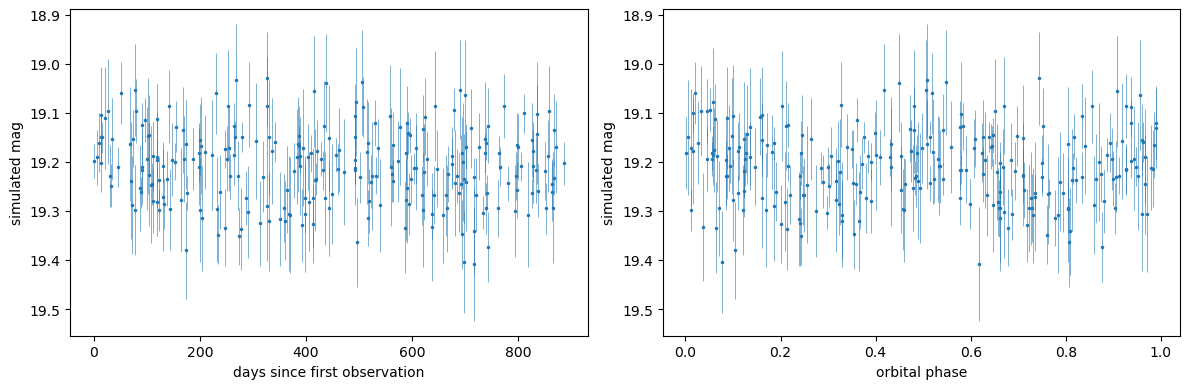

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].errorbar(
    demo_injected["hjd"] - demo_injected["hjd"].min(),
    demo_injected["sim_mag"],
    demo_injected["sim_magerr"],
    fmt=".",
    ms=3,
    lw=0.4,
)
axs[0].invert_yaxis()
axs[0].set_xlabel("days since first observation")
axs[0].set_ylabel("simulated mag")

axs[1].errorbar(
    demo_injected["phase"],
    demo_injected["sim_mag"],
    demo_injected["sim_magerr"],
    fmt=".",
    ms=3,
    lw=0.4,
)
axs[1].invert_yaxis()
axs[1].set_xlabel("orbital phase")
axs[1].set_ylabel("simulated mag")

fig.tight_layout()


## End-to-End Example on One Real SCoPe Match

This cell loads one non-variable WD/SCoPe match, fetches its real ZTF cadence, samples one WDB model, injects the model into the observed cadence/noise, and plots the result.


In [56]:
if wd_matches.empty:
    raise ValueError("No WD/SCoPe matches loaded. Run scope_gaia_crossmatch.ipynb first or update matches_path.")

example_match = wd_matches.iloc[0]
example_obs_lc = load_scope_lightcurve_for_match(example_match, drop_flagged=False)

# Use the filter with the most observations for the injection.
example_filter = int(example_obs_lc["filter"].value_counts().idxmax())
example_params, example_sim_lc, example_lcurve_result = draw_accepted_wdb_injection(
    example_obs_lc,
    rng,
    mode=prior_mode,
    filter_id=example_filter,
    min_amp_mag=min_clean_amp_mag,
    max_attempts=max_acceptance_attempts,
)

print(f"SCoPe source _id: {example_match.get('_id')}")
print(f"Gaia source_id: {example_match.get('gaia_source_id')}")
print(f"Using filter: {example_filter}; observations: {len(example_sim_lc)}")
print(example_lcurve_result)
pd.Series(example_params)


SCoPe source _id: 10561631008663.0
Gaia source_id: 3414174167649676800
Using filter: 1; observations: 191
LcResult(npoints=191, wdwarf=7.650693e-10, chisq=0.0000, logg1=0.0000, logg2=0.0000)


period_days                0.007202
q                          1.080228
iangle                    89.437650
r1                         0.010353
r2                         0.034197
t1                     49740.218549
t2                     13781.867892
phase0                     0.495370
amplitude_scale            4.268103
blend_fraction             0.018095
spin1                      1.000000
spin2                      1.000000
ldc1_1                     0.413511
ldc2_1                     0.249914
ldc1_2                     0.000000
ldc1_3                     0.000000
ldc1_4                     0.000000
ldc2_2                     0.000000
ldc2_3                     0.000000
ldc2_4                     0.000000
gravity_dark1              0.250000
gravity_dark2              0.250000
beam_factor1               0.801853
beam_factor2               1.967644
clean_amp_mag              0.059780
acceptance_attempts       27.000000
dtype: float64

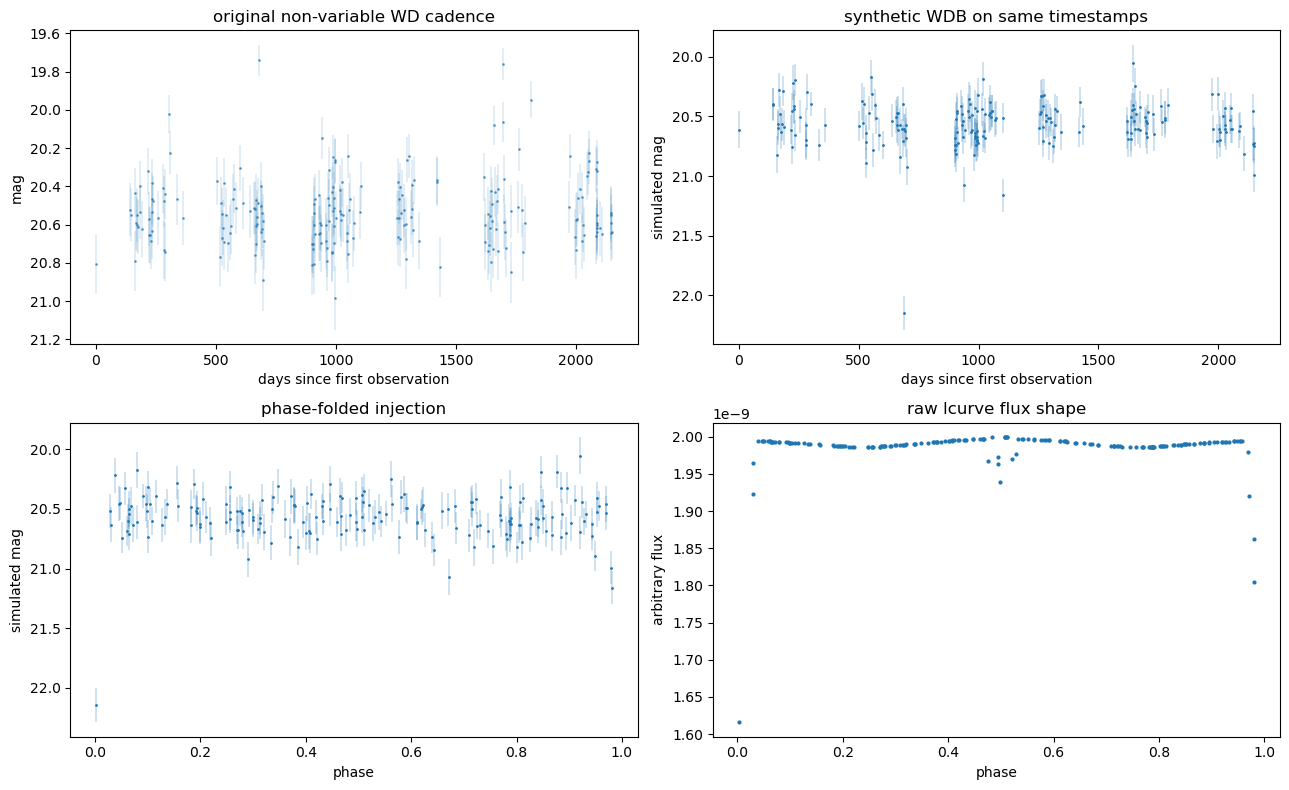

In [57]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8))

axs[0, 0].errorbar(
    example_obs_lc["hjd"] - example_obs_lc["hjd"].min(),
    example_obs_lc["mag"],
    example_obs_lc["magerr"],
    fmt=".",
    ms=2,
    lw=0.3,
    alpha=0.6,
)
axs[0, 0].invert_yaxis()
axs[0, 0].set_title("original non-variable WD cadence")
axs[0, 0].set_xlabel("days since first observation")
axs[0, 0].set_ylabel("mag")

axs[0, 1].errorbar(
    example_sim_lc["hjd"] - example_sim_lc["hjd"].min(),
    example_sim_lc["sim_mag"],
    example_sim_lc["sim_magerr"],
    fmt=".",
    ms=2,
    lw=0.3,
)
axs[0, 1].invert_yaxis()
axs[0, 1].set_title("synthetic WDB on same timestamps")
axs[0, 1].set_xlabel("days since first observation")
axs[0, 1].set_ylabel("simulated mag")

axs[1, 0].errorbar(
    example_sim_lc["phase"],
    example_sim_lc["sim_mag"],
    example_sim_lc["sim_magerr"],
    fmt=".",
    ms=2,
    lw=0.3,
)
axs[1, 0].invert_yaxis()
axs[1, 0].set_title("phase-folded injection")
axs[1, 0].set_xlabel("phase")
axs[1, 0].set_ylabel("simulated mag")

axs[1, 1].scatter(example_sim_lc["phase"], example_sim_lc["raw_lcurve_flux"], s=4)
axs[1, 1].set_title("raw lcurve flux shape")
axs[1, 1].set_xlabel("phase")
axs[1, 1].set_ylabel("arbitrary flux")

fig.tight_layout()
plt.savefig('test_plot.png')


## Batch Injection Loop

After `load_scope_lightcurve_for_match` is implemented, this loop will generate one synthetic WDB injection for each non-variable WD match.

In [58]:
def make_source_diagnostic_plot(obs_lc, sim_lc, params, sim_id, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    obs_time = obs_lc["hjd"].to_numpy(dtype=float) - float(obs_lc["hjd"].min())
    sim_time = sim_lc["hjd"].to_numpy(dtype=float) - float(sim_lc["hjd"].min())
    raw_flux = sim_lc["raw_lcurve_flux"].to_numpy(dtype=float)
    raw_flux = raw_flux / np.nanmedian(raw_flux)

    fig, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

    axs[0, 0].errorbar(
        obs_time,
        obs_lc["mag"],
        obs_lc["magerr"],
        fmt=".",
        ms=2,
        lw=0.3,
        alpha=0.7,
    )
    axs[0, 0].invert_yaxis()
    axs[0, 0].set_title("original Gaia/SCoPe WD")
    axs[0, 0].set_xlabel("days since first observation")
    axs[0, 0].set_ylabel("mag")

    axs[0, 1].plot(sim_time, raw_flux, ".", ms=2, lw=0.3, alpha=0.7)
    axs[0, 1].set_title("pure simulated WDB")
    axs[0, 1].set_xlabel("days since first observation")
    axs[0, 1].set_ylabel("relative flux")

    axs[0, 2].plot(sim_lc["phase"], raw_flux, ".", ms=2, lw=0.3, alpha=0.7)
    axs[0, 2].set_title("pure simulated WDB")
    axs[0, 2].set_xlabel("orbital phase")
    axs[0, 2].set_ylabel("relative flux")

    axs[1, 0].errorbar(
        sim_time,
        sim_lc["sim_mag"],
        sim_lc["sim_magerr"],
        fmt=".",
        ms=2,
        lw=0.3,
        alpha=0.7,
    )
    axs[1, 0].invert_yaxis()
    axs[1, 0].set_title("rescaled WDB + injected noise")
    axs[1, 0].set_xlabel("days since first observation")
    axs[1, 0].set_ylabel("mag")

    axs[1, 1].errorbar(
        sim_lc["phase"],
        sim_lc["sim_mag"],
        sim_lc["sim_magerr"],
        fmt=".",
        ms=2,
        lw=0.3,
        alpha=0.7,
    )
    axs[1, 1].invert_yaxis()
    axs[1, 1].set_title("rescaled WDB + injected noise")
    axs[1, 1].set_xlabel("orbital phase")
    axs[1, 1].set_ylabel("mag")

    axs[1, 2].axis("off")
    summary = (
        f"sim_id: {sim_id}\n"
        f"source_id: {params.get('source_id', 'n/a')}\n"
        f"gaia_source_id: {params.get('gaia_source_id', 'n/a')}\n"
        f"period_days: {params.get('period_days', np.nan):.6f}\n"
        f"clean_amp_mag: {params.get('clean_amp_mag', np.nan):.3f}\n"
        f"filter: {params.get('filter', 'n/a')}"
    )
    axs[1, 2].text(0.0, 0.95, summary, va="top", family="monospace")

    out_path = out_dir / f"{sim_id}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


def simulate_batch(
    wd_matches,
    n_systems=25,
    mode="informed",
    seed=1,
    filter_id=None,
    min_amp_mag=0.05,
    max_attempts=100,
    plot_dir="data/simulated_wdb_batch/diagnostic_plots",
):
    local_rng = np.random.default_rng(seed)
    rows = []
    lightcurves = {}

    for idx, match in wd_matches.head(n_systems).iterrows():
        obs_lc = load_scope_lightcurve_for_match(match)
        use_filter = filter_id
        if use_filter is None and "filter" in obs_lc.columns:
            use_filter = int(obs_lc["filter"].value_counts().idxmax())

        obs_lc = prepare_observed_lightcurve(obs_lc, filter_id=use_filter)

        params, sim_lc, lc_result = draw_accepted_wdb_injection(
            obs_lc,
            local_rng,
            mode=mode,
            filter_id=use_filter,
            min_amp_mag=min_amp_mag,
            max_attempts=max_attempts,
        )

        sim_id = f"sim_{idx:05d}"
        sim_lc = sim_lc.copy()
        sim_lc["sim_id"] = sim_id
        sim_lc["source_id"] = match.get("_id", np.nan)
        sim_lc["ra"] = match.get("ra", np.nan)
        sim_lc["dec"] = match.get("dec", np.nan)
        sim_lc["field"] = match.get("field", np.nan)
        sim_lc["ccd"] = match.get("ccd", np.nan)
        sim_lc["quad"] = match.get("quad", np.nan)
        lightcurves[sim_id] = sim_lc

        meta = dict(params)
        meta.update({
            "sim_id": sim_id,
            "source_id": match.get("_id", np.nan),
            "gaia_source_id": match.get("gaia_source_id", np.nan),
            "ra": match.get("ra", np.nan),
            "dec": match.get("dec", np.nan),
            "field": match.get("field", np.nan),
            "ccd": match.get("ccd", np.nan),
            "quad": match.get("quad", np.nan),
            "filter": use_filter,
            "n_obs": len(sim_lc),
            "logg1": lc_result.logg1,
            "logg2": lc_result.logg2,
            "rv1": lc_result.rv1,
            "rv2": lc_result.rv2,
        })
        rows.append(meta)

        if plot_dir is not None:
            make_source_diagnostic_plot(obs_lc, sim_lc, meta, sim_id, plot_dir)

    return pd.DataFrame(rows), lightcurves


In [59]:
SIM_BATCH_DIR = Path("data/simulated_wdb_batch")
SIM_BATCH_DIR.mkdir(parents=True, exist_ok=True)


def save_simulated_batch(sim_meta, sim_lightcurves, output_dir=SIM_BATCH_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    sim_meta.to_parquet(output_dir / "sim_meta.parquet", index=False)
    with open(output_dir / "sim_lightcurves.pkl", "wb") as f:
        pickle.dump(sim_lightcurves, f)
    return output_dir / "sim_meta.parquet", output_dir / "sim_lightcurves.pkl"


def load_simulated_batch(input_dir=SIM_BATCH_DIR):
    input_dir = Path(input_dir)
    sim_meta = pd.read_parquet(input_dir / "sim_meta.parquet")
    with open(input_dir / "sim_lightcurves.pkl", "rb") as f:
        sim_lightcurves = pickle.load(f)
    return sim_meta, sim_lightcurves


N_SIM_SYSTEMS = 10
SIM_SEED = 123

sim_meta, sim_lightcurves = simulate_batch(
    wd_matches,
    n_systems=N_SIM_SYSTEMS,
    mode=prior_mode,
    seed=SIM_SEED,
    min_amp_mag=min_clean_amp_mag,
    max_attempts=max_acceptance_attempts,
)

sim_meta_path, sim_lightcurves_path = save_simulated_batch(sim_meta, sim_lightcurves)
print(f"Saved {len(sim_meta)} simulated systems")
print(sim_meta_path)
print(sim_lightcurves_path)
sim_meta.head()


Saved 10 simulated systems
data/simulated_wdb_batch/sim_meta.parquet
data/simulated_wdb_batch/sim_lightcurves.pkl


,period_days,q,iangle,r1,r2,t1,t2,phase0,amplitude_scale,blend_fraction,...,dec,field,ccd,quad,filter,n_obs,logg1,logg2,rv1,rv2
0,0.043460,1.413578,89.145222,0.029405,0.034861,37788.448474,6182.661789,0.375568,3.553778,0.051053,...,21.065998,561.0,16.0,4.0,1,191,0.0,0.0,0.029405,0.034859
1,0.018104,1.097666,80.771637,0.020625,0.030784,35011.493096,5010.667760,0.473817,5.151380,0.272105,...,28.331561,637.0,15.0,4.0,1,423,0.0,0.0,0.020625,0.030783
2,0.012457,1.015588,89.211772,0.018546,0.027215,14407.515023,12052.703071,0.288696,4.527430,0.435731,...,6.787609,489.0,15.0,4.0,2,465,0.0,0.0,0.018546,0.027214
3,0.481801,1.139194,81.477841,0.014967,0.038433,28032.781804,6514.963661,0.955039,5.967852,0.291841,...,28.240863,637.0,14.0,4.0,1,486,0.0,0.0,0.014967,0.038430
4,0.007802,0.493565,82.887037,0.010520,0.012704,41960.521525,7215.835544,0.497019,7.663701,0.295182,...,42.302462,699.0,12.0,1.0,1,289,0.0,0.0,0.010520,0.012704


In [60]:
sim_meta

,period_days,q,iangle,r1,r2,t1,t2,phase0,amplitude_scale,blend_fraction,...,dec,field,ccd,quad,filter,n_obs,logg1,logg2,rv1,rv2
0,0.043460,1.413578,89.145222,0.029405,0.034861,37788.448474,6182.661789,0.375568,3.553778,0.051053,...,21.065998,561.0,16.0,4.0,1,191,0.0,0.0,0.029405,0.034859
1,0.018104,1.097666,80.771637,0.020625,0.030784,35011.493096,5010.667760,0.473817,5.151380,0.272105,...,28.331561,637.0,15.0,4.0,1,423,0.0,0.0,0.020625,0.030783
2,0.012457,1.015588,89.211772,0.018546,0.027215,14407.515023,12052.703071,0.288696,4.527430,0.435731,...,6.787609,489.0,15.0,4.0,2,465,0.0,0.0,0.018546,0.027214
3,0.481801,1.139194,81.477841,0.014967,0.038433,28032.781804,6514.963661,0.955039,5.967852,0.291841,...,28.240863,637.0,14.0,4.0,1,486,0.0,0.0,0.014967,0.038430
4,0.007802,0.493565,82.887037,0.010520,0.012704,41960.521525,7215.835544,0.497019,7.663701,0.295182,...,42.302462,699.0,12.0,1.0,1,289,0.0,0.0,0.010520,0.012704
5,0.426728,1.135736,84.524387,0.031198,0.036263,35037.069669,6149.743211,0.129556,5.472262,0.039663,...,27.179220,636.0,10.0,1.0,1,404,0.0,0.0,0.031198,0.036260
6,0.265126,1.093120,82.376944,0.021489,0.028856,33157.380050,8322.308136,0.583815,5.401539,0.203391,...,59.554500,825.0,2.0,2.0,1,1671,0.0,0.0,0.021489,0.028855
7,0.062934,1.110626,84.633809,0.019276,0.008997,18715.866629,17670.265933,0.809414,7.446609,0.166603,...,8.187181,538.0,2.0,4.0,1,162,0.0,0.0,0.019276,0.008997
8,0.031392,1.087144,88.192996,0.037362,0.021716,45093.596744,15930.353485,0.744105,6.534332,0.005158,...,33.614665,684.0,10.0,3.0,2,1112,0.0,0.0,0.037362,0.021716
9,0.120054,0.430797,77.818541,0.037684,0.013515,20281.977023,6755.296965,0.011396,6.526586,0.090029,...,7.596723,487.0,16.0,1.0,2,549,0.0,0.0,0.037684,0.013515


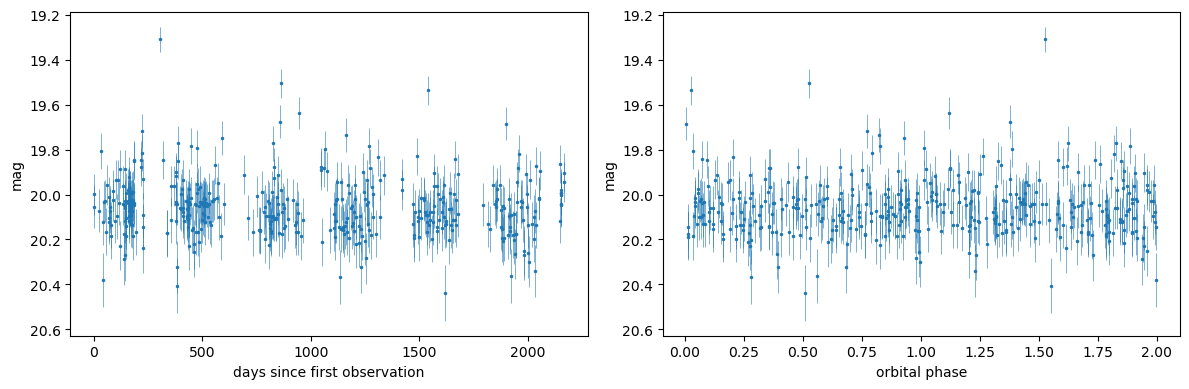

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].errorbar(
    sim_lightcurves['sim_00001']["hjd"] - sim_lightcurves['sim_00001']["hjd"].min(),
    sim_lightcurves['sim_00001']["mag"],
    sim_lightcurves['sim_00001']["magerr"],
    fmt=".",
    ms=3,
    lw=0.4,
)
axs[0].invert_yaxis()
axs[0].set_xlabel("days since first observation")
axs[0].set_ylabel("mag")

period = sim_meta['period_days'][0]

axs[1].errorbar(
    (sim_lightcurves['sim_00001']["hjd"] % (2*period))/(period), # sim_lightcurves['sim_00000']["phase"],
    sim_lightcurves['sim_00001']["mag"],
    sim_lightcurves['sim_00001']["magerr"],
    fmt=".",
    ms=3,
    lw=0.4,
)
axs[1].invert_yaxis()
axs[1].set_xlabel("orbital phase")
axs[1].set_ylabel("mag")

fig.tight_layout()